# Model-6: Caltech 256 Dataset, Resize to 256x256, Sigmoid in Final Layers, Multi Scale Parallel Hiding Network

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import torch.nn.functional as F

import torchvision
from torchvision import datasets

In [2]:
try:
    from torchinfo import summary
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "torchinfo"])
    from torchinfo import summary

In [3]:
try:
    import torchmetrics
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "torchmetrics"])
    import torchmetrics

In [4]:
import os
repo_url = "https://raw.githubusercontent.com/vardanskamra/Deep-Multimedia-Steganography/main/utils"
files = [
    "__init__.py",
    "test.py",
    "train.py",
    "metrics.py",
    "transforms.py",
    "visualizations.py",
    "inference.py"
]
os.makedirs("utils", exist_ok=True)

for file in files:
    file_url = f"{repo_url}/{file}"
    os.system(f"curl -s {file_url} -o utils/{file}")

print("Downloaded all utils files successfully!")

Downloaded all utils files successfully!


In [5]:
import sys
sys.path.append("./utils") 

In [6]:
import utils

from utils.transforms import caltech256_train_test_transform_256x256
from utils.metrics import loss_function
from utils.train import train
from utils.test import test

from utils.visualizations import plot_metrics
from utils.visualizations import visualize_images

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
dataset = datasets.Caltech256(root='./data', download=True, transform=caltech256_train_test_transform_256x256)

# Using x% of the dataset
subset_size = int(1 * len(dataset))  
train_size = int(0.8 * subset_size)  
test_size = subset_size - train_size  

subset_dataset, _ = torch.utils.data.random_split(dataset, [subset_size, len(dataset) - subset_size])

train_dataset, test_dataset = torch.utils.data.random_split(subset_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=os.cpu_count(), drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, drop_last=True)


Downloading...
From (original): https://drive.google.com/uc?id=1r6o0pSROcV1_VwT4oSjA2FBUSCWGuxLK
From (redirected): https://drive.usercontent.google.com/download?id=1r6o0pSROcV1_VwT4oSjA2FBUSCWGuxLK&confirm=t&uuid=238d7b8f-0ab7-4e48-83b8-3c6b166dd218
To: /kaggle/working/data/caltech256/256_ObjectCategories.tar
100%|██████████| 1.18G/1.18G [00:33<00:00, 35.2MB/s]


Extracting ./data/caltech256/256_ObjectCategories.tar to ./data/caltech256


In [9]:
def get_min_max(loader):
    min_vals = []
    max_vals = []
    
    for inputs, _ in loader:
        # Flatten the inputs tensor to make sure we check all values
        min_vals.append(inputs.min().item())
        max_vals.append(inputs.max().item())
    
    # Calculate the overall min and max across the dataset
    overall_min = min(min_vals)
    overall_max = max(max_vals)
    
    return overall_min, overall_max

# Get the min and max values for the train dataset
train_min, train_max = get_min_max(train_loader)
print(f"Train dataset - Min: {train_min}, Max: {train_max}")

# Get the min and max values for the test dataset
test_min, test_max = get_min_max(test_loader)
print(f"Test dataset - Min: {test_min}, Max: {test_max}")

Train dataset - Min: 0.0, Max: 1.0
Test dataset - Min: 0.0, Max: 1.0


In [10]:
print(f"Train Dataset Length: {len(train_dataset)}")
print(f"Test Dataset Length: {len(test_dataset)}")
print(f"Train DataLoader Length: {len(train_loader)}")
print(f"Test DataLoader Length: {len(test_loader)}")

sample, label = next(iter(train_loader))
print(f"Sample Shape: {sample.shape}")
print(f"Label Shape: {label.shape}")

Train Dataset Length: 24485
Test Dataset Length: 6122
Train DataLoader Length: 765
Test DataLoader Length: 191
Sample Shape: torch.Size([32, 3, 256, 256])
Label Shape: torch.Size([32])


In [11]:
class PrepNetwork(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super(PrepNetwork, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, out_channels, kernel_size=3, padding=1)
        self.silu = nn.SiLU()
    
    def forward(self, x):
        x = self.silu(self.conv1(x))
        x = self.silu(self.conv2(x))
        x = self.conv3(x)  # No activation here to allow flexibility
        return x

In [12]:
class HidingNetwork(nn.Module):
    def __init__(self, in_channels=6, out_channels=3):
        super(HidingNetwork, self).__init__()

        # Encoder
        self.enc1 = self.conv_block(in_channels, 64)
        self.enc2 = self.conv_block(64, 128)
        self.enc3 = self.conv_block(128, 256)
        self.enc4 = self.conv_block(256, 512)

        # Bottleneck
        self.bottleneck = self.conv_block(512, 1024)

        # Decoder
        self.upconv4 = self.upconv_block(1024, 512)
        self.dec4 = self.conv_block(1024, 512)

        self.upconv3 = self.upconv_block(512, 256)
        self.dec3 = self.conv_block(512, 256)

        self.upconv2 = self.upconv_block(256, 128)
        self.dec2 = self.conv_block(256, 128)

        self.upconv1 = self.upconv_block(128, 64)
        self.dec1 = self.conv_block(128, 64)

        # Final output layer
        self.final = nn.Conv2d(64, out_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.SiLU()
        )

    def upconv_block(self, in_channels, out_channels):
        return nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

    def forward(self, cover, secret_prepared):
        x = torch.cat([cover, secret_prepared], dim=1)

        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(F.max_pool2d(e1, 2))
        e3 = self.enc3(F.max_pool2d(e2, 2))
        e4 = self.enc4(F.max_pool2d(e3, 2))

        # Bottleneck
        b = self.bottleneck(F.max_pool2d(e4, 2))

        # Decoder with Skip Connections
        d4 = self.upconv4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.upconv3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.upconv2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.upconv1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.sigmoid(self.final(d1))

In [13]:
class RevealNetwork(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super(RevealNetwork, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 128, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, out_channels, kernel_size=3, padding=1)
        self.silu = nn.SiLU()
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.silu(self.conv1(x))
        x = self.silu(self.conv2(x))
        return self.sigmoid(self.conv3(x))

In [14]:
print(f"Device: {device}")
prep_net = nn.DataParallel(PrepNetwork()).to(device)
hide_net = nn.DataParallel(HidingNetwork()).to(device)
reveal_net = nn.DataParallel(RevealNetwork()).to(device)

Device: cuda


In [15]:
print("PrepNetwork Summary:")
print(summary(prep_net, input_size=(32, 3, 128, 128)))

cover = torch.randn(32, 3, 128, 128).to(device)
secret_prepared = torch.randn(32, 3, 128, 128).to(device)

print("\nHidingNetwork Summary:")
print(summary(hide_net, input_data=[cover, secret_prepared])) # 6 channels (cover + secret_prepared)

print("\nRevealNetwork Summary:")
print(summary(reveal_net, input_size=(32, 3, 128, 128)))

PrepNetwork Summary:
Layer (type:depth-idx)                   Output Shape              Param #
DataParallel                             [32, 3, 128, 128]         --
├─PrepNetwork: 1-1                       [16, 3, 128, 128]         79,107
├─PrepNetwork: 1-4                       --                        (recursive)
│    └─Conv2d: 2-1                       [16, 64, 128, 128]        1,792
├─PrepNetwork: 1-3                       [16, 3, 128, 128]         --
├─PrepNetwork: 1-4                       --                        (recursive)
│    └─Conv2d: 2-2                       [16, 64, 128, 128]        --
│    └─SiLU: 2-3                         [16, 64, 128, 128]        --
│    └─SiLU: 2-4                         [16, 64, 128, 128]        --
│    └─Conv2d: 2-5                       [16, 128, 128, 128]       73,856
│    └─Conv2d: 2-6                       [16, 128, 128, 128]       --
│    └─SiLU: 2-7                         [16, 128, 128, 128]       --
│    └─SiLU: 2-8                   

In [16]:
optimizer = torch.optim.Adam(list(prep_net.parameters()) +
                       list(hide_net.parameters()) +
                       list(reveal_net.parameters()), lr=0.001)

In [17]:
train_metrics = train(dataloader=train_loader,
                prep_net=prep_net,
                hide_net=hide_net,
                reveal_net=reveal_net,
                optimizer=optimizer,
                loss_fn=loss_function,
                beta=0.75,
                epochs=10,
                device=device)

/usr/local/lib/python3.10/dist-packages/torchmetrics/utilities/prints.py:62: FutureWarning: Importing `PeakSignalNoiseRatio` from `torchmetrics` was deprecated and will be removed in 2.0. Import `PeakSignalNoiseRatio` from `torchmetrics.image` instead.
  _future_warning(
/usr/local/lib/python3.10/dist-packages/torchmetrics/utilities/prints.py:62: FutureWarning: Importing `StructuralSimilarityIndexMeasure` from `torchmetrics` was deprecated and will be removed in 2.0. Import `StructuralSimilarityIndexMeasure` from `torchmetrics.image` instead.
  _future_warning(


Epoch [1/10], Loss: 0.0264, PSNR: 20.7282, SSIM: 0.8165, NC: 0.8701, Pixel Loss (Cover-Stego): 0.0721, Pixel Loss (Secret-Revealed): 0.1091
Epoch [2/10], Loss: 0.0155, PSNR: 22.6179, SSIM: 0.8665, NC: 0.9430, Pixel Loss (Cover-Stego): 0.0562, Pixel Loss (Secret-Revealed): 0.0831
Epoch [3/10], Loss: 0.0131, PSNR: 23.5048, SSIM: 0.8865, NC: 0.9482, Pixel Loss (Cover-Stego): 0.0506, Pixel Loss (Secret-Revealed): 0.0747
Epoch [4/10], Loss: 0.0112, PSNR: 24.4056, SSIM: 0.8968, NC: 0.9524, Pixel Loss (Cover-Stego): 0.0449, Pixel Loss (Secret-Revealed): 0.0678
Epoch [5/10], Loss: 0.0107, PSNR: 24.7818, SSIM: 0.8980, NC: 0.9536, Pixel Loss (Cover-Stego): 0.0427, Pixel Loss (Secret-Revealed): 0.0665
Epoch [6/10], Loss: 0.0103, PSNR: 25.0151, SSIM: 0.9026, NC: 0.9548, Pixel Loss (Cover-Stego): 0.0411, Pixel Loss (Secret-Revealed): 0.0651
Epoch [7/10], Loss: 0.0099, PSNR: 25.3274, SSIM: 0.9070, NC: 0.9555, Pixel Loss (Cover-Stego): 0.0394, Pixel Loss (Secret-Revealed): 0.0641
Epoch [8/10], Loss: 

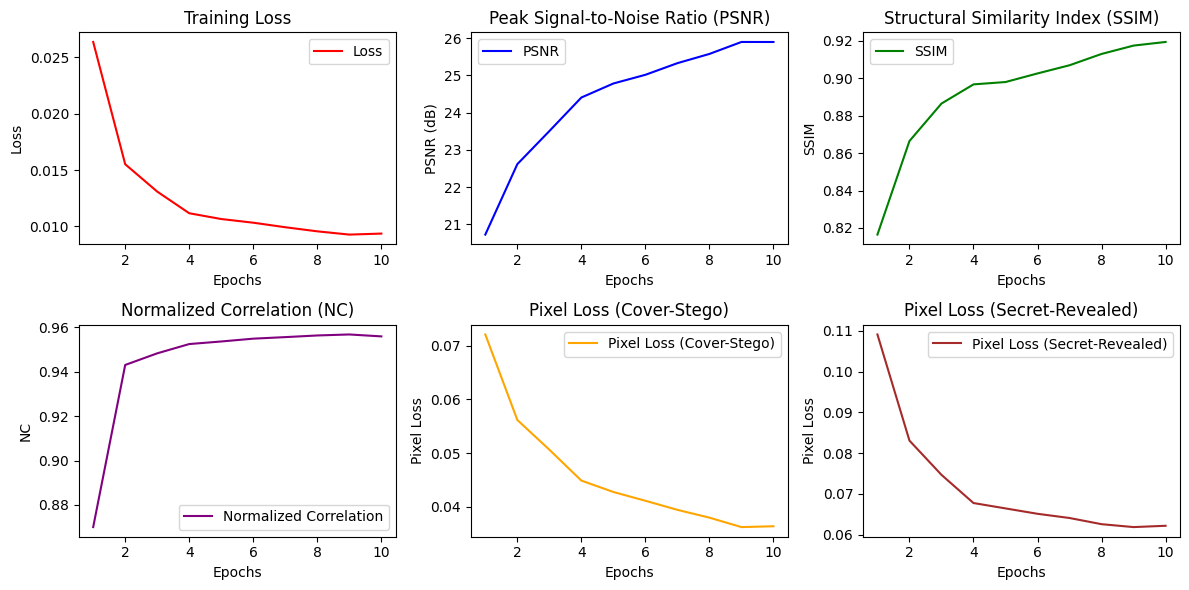


Final Evaluation Metrics:
Final Loss: 0.0094
Final PSNR: 25.8950 dB
Final SSIM: 0.9194
Final Normalized Correlation (NC): 0.9559
Final Pixel Loss (Cover-Stego): 0.0364
Final Pixel Loss (Secret-Revealed): 0.0622



In [18]:
plot_metrics(train_metrics)

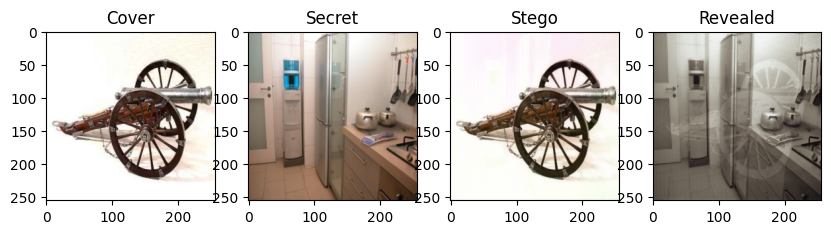

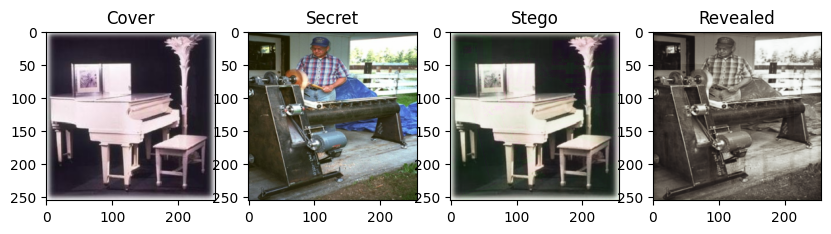

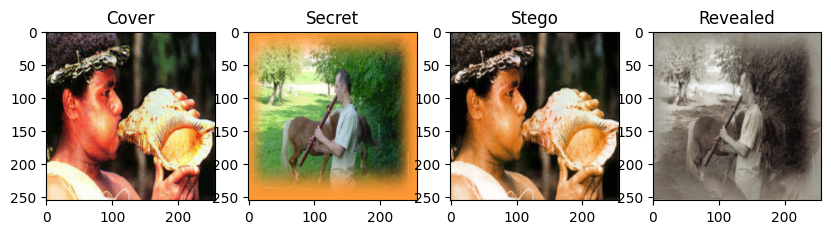

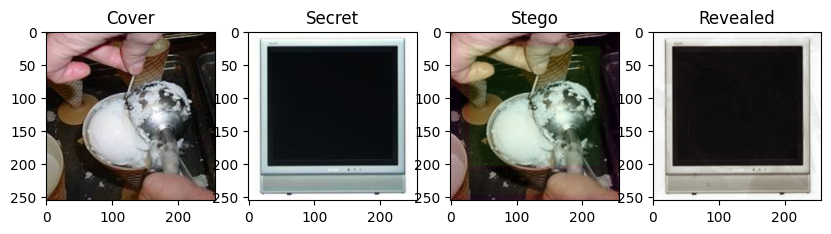

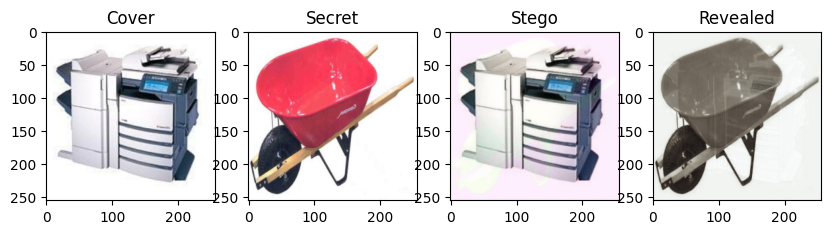

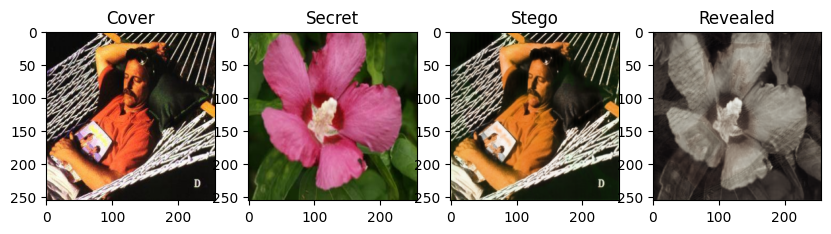

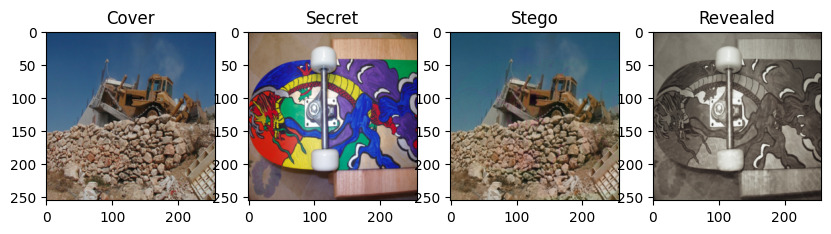

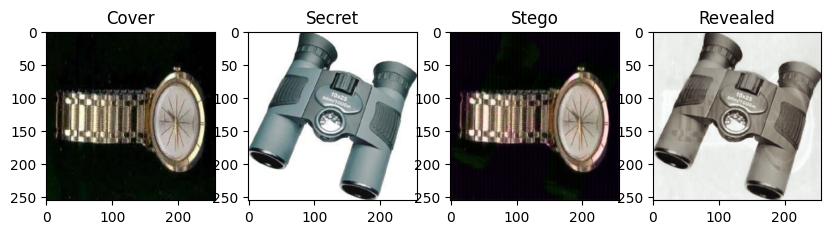

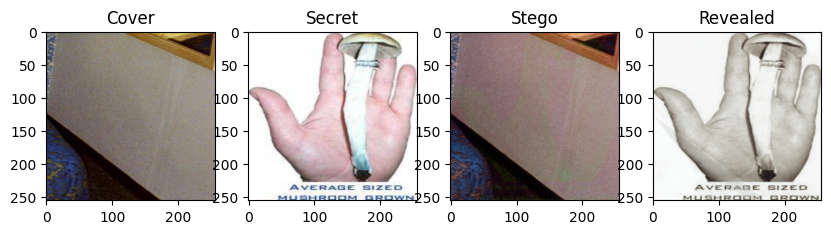


Test Results: Loss: 0.0094, PSNR: 27.1526, SSIM: 0.9325, NC: 0.9544, Pixel Loss (Cover-Stego): 0.0300, Pixel Loss (Secret-Revealed): 0.0685



In [19]:
test_metrics = test(prep_net=prep_net,
               hide_net=hide_net,
               reveal_net=reveal_net,
               dataloader=test_loader,
               loss_fn = loss_function,
               beta = 0.75,
               visualize = True,
               device=device)

In [20]:
torch.save(prep_net.state_dict(), "/kaggle/working/prep_net.pth")
torch.save(hide_net.state_dict(), "/kaggle/working/hide_net.pth")
torch.save(reveal_net.state_dict(), "/kaggle/working/reveal_net.pth")